# Tutorial 5: Multi-section ABC-WMB analysis

This tutorial shows how to inspect a precomputed multi-section GraphPCA-Turbo model for the ABC-WMB MERFISH atlas. We use three consecutive sections (`C57BL6J-638850.13`–`.15`) to demonstrate data loading, the preprocessing contract, loading a saved model, rotation-aware program interpretation, anatomical summaries, and serial-section checks.

The complete atlas contains 3,938,808 cells across 59 sections. Re-fitting the full model is intentionally not part of this tutorial. The repository contains only a compact, plot-ready sample derived from the saved fit, so every figure below is visible without distributing the raw atlas or large embedding files.

## Goal

By the end of the tutorial, you will be able to:

1. connect an ABC-WMB expression object to section metadata;
2. reproduce the preprocessing used by the multi-section analysis;
3. load saved section embeddings (`Z_s`), the shared loading matrix (`W_0`), and a common rotation;
4. visualize shared molecular programs across three sections;
5. inspect leading loading genes and post hoc anatomical associations; and
6. assess shared-versus-section-specific loadings and serial continuity.

## Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

SECTIONS = ["C57BL6J-638850.13", "C57BL6J-638850.14", "C57BL6J-638850.15"]
PROGRAM_LABELS = {
    "P01": "Endothelial / BBB",
    "P02": "Oligodendrocyte / myelin",
    "P05": "Astroglial",
    "P08": "Striatal Drd2 / Penk",
    "P14": "Choroid plexus epithelium",
    "P26": "Ependymal / ventricular",
}

# Set this to True only on a workstation with the complete ABC-WMB files.
RUN_FULL_DATA = False
RAW_H5AD = Path("/path/to/ABC_WMB_expression_and_metadata.h5ad")
STORE_ROOT = Path("/path/to/ABC_WMB_section_store")
MODEL_DIR = Path("/path/to/precomputed/ABC_WMB_global_model")

candidate_asset_dirs = [Path("_static/abc_wmb_tutorial"), Path("source/_static/abc_wmb_tutorial")]
ASSET_DIR = next(path for path in candidate_asset_dirs if path.exists())
ASSET_DIR

PosixPath('_static/abc_wmb_tutorial')

### What is bundled?

The compact table contains a fixed random sample of 6,000 cells per section, their within-section coordinates, CCF annotations, and six program scores calculated from the saved model. It is sufficient for plotting but is not a substitute for the raw expression matrix.

In [2]:
with open(ASSET_DIR / "analysis_summary.json") as handle:
    analysis_summary = json.load(handle)

section_manifest = pd.read_csv(ASSET_DIR / "three_section_manifest.csv")
demo_cells = pd.read_csv(ASSET_DIR / "three_section_program_scores.csv.gz")

print("Full fitted atlas:", analysis_summary)
section_manifest

Full fitted atlas: {'cells': 3938808, 'sections': 59, 'genes': 500, 'programs': 30, 'graph_lambda': 0.5, 'sharing_eta': 0.01, 'converged': True, 'outer_iterations': 63}


,section,section_order,n_cells,n_genes,graph_nnz
0,C57BL6J-638850.13,11,71231,500,809776
1,C57BL6J-638850.14,12,94385,500,1072696
2,C57BL6J-638850.15,13,80333,500,916354


## 1. Read the complete data locally

The ABC-WMB object is too large for GitHub. The following cell documents the expected local input contract. It is skipped in the published tutorial, but can be activated after replacing `RAW_H5AD` with a local file. The object should contain the 500 measured genes, section identifiers, within-section coordinates, and the Allen CCF annotations used only for post hoc evaluation.

In [3]:
if RUN_FULL_DATA:
    import scanpy as sc

    adata = sc.read_h5ad(RAW_H5AD, backed="r")
    required_obs = {
        "brain_section_label", "x_section", "y_section", "z_section",
        "parcellation_division", "parcellation_structure", "subclass",
    }
    missing = required_obs.difference(adata.obs.columns)
    if missing:
        raise ValueError(f"Missing required metadata columns: {sorted(missing)}")
    print(adata)
    print(adata.obs.loc[adata.obs["brain_section_label"].isin(SECTIONS), sorted(required_obs)].head())
    example_mask = adata.obs["brain_section_label"].eq(SECTIONS[0]).to_numpy()
    example_section = adata[example_mask].to_memory()
    print("Materialized one section for preprocessing:", example_section)
else:
    print("Full-data read skipped. Set RUN_FULL_DATA=True after assigning RAW_H5AD.")

Full-data read skipped. Set RUN_FULL_DATA=True after assigning RAW_H5AD.


## 2. Reproduce the preprocessing contract

For the reported fit, blank codewords were removed, counts were normalized within cells and transformed with `log1p`, and the 500-gene panel was scaled by gene-wise standard deviations estimated across the complete atlas. Each section was centered implicitly during optimization. A 10-nearest-neighbor spatial graph was constructed independently within each section, preventing edges from crossing section boundaries.

The code below is a compact template. For a production run, store each section as a sparse matrix and avoid materializing all sections simultaneously.

In [4]:
def prepare_one_section(adata_section, global_gene_sd, n_neighbors=10):
    import scanpy as sc
    from sklearn.neighbors import kneighbors_graph

    work = adata_section.copy()
    sc.pp.normalize_total(work, target_sum=1e4)
    sc.pp.log1p(work)

    # Scale by atlas-level SD. The optimizer handles within-section centering.
    work.X = work.X.multiply(1.0 / global_gene_sd) if hasattr(work.X, "multiply") else work.X / global_gene_sd
    coordinates = work.obs[["x_section", "y_section"]].to_numpy()
    graph = kneighbors_graph(coordinates, n_neighbors=n_neighbors, mode="connectivity")
    graph = graph.maximum(graph.T)
    return work, graph

if RUN_FULL_DATA:
    # First pass: estimate global gene SD after normalize_total + log1p.
    # Second pass: call prepare_one_section for each section and write sparse stores.
    print("Run the two-pass preprocessing here using your local sparse-data workflow.")
else:
    print("Preprocessing template defined; no raw counts are distributed with the tutorial.")

Preprocessing template defined; no raw counts are distributed with the tutorial.


## 3. Load the saved multi-section representation

The fitted model stores one embedding matrix `Z_s` and one loading matrix `W_s` per section, together with the global loading center `W_0`. Because loading coordinates are invariant to orthogonal rotation, all program-level displays use the same Varimax rotation and deterministic sign orientation. Applying one common rotation preserves cross-section comparability.

In [5]:
if RUN_FULL_DATA:
    common_rotation = np.load(MODEL_DIR / "interpretability/common_varimax_rotation.npy")
    global_loadings = np.load(MODEL_DIR / "W0.npy") @ common_rotation
    section_loadings = np.load(MODEL_DIR / "Ws.npy") @ common_rotation

    full_scores = {}
    for section in SECTIONS:
        embedding = np.load(MODEL_DIR / "embeddings" / f"{section}_Z.npy", mmap_mode="r")
        full_scores[section] = np.asarray(embedding) @ common_rotation
    print("W0:", global_loadings.shape, "Ws:", section_loadings.shape)
    print({key: value.shape for key, value in full_scores.items()})
else:
    print("Using compact program scores already transformed by the saved common rotation.")

Using compact program scores already transformed by the saved common rotation.


## 4. Inspect the three consecutive sections

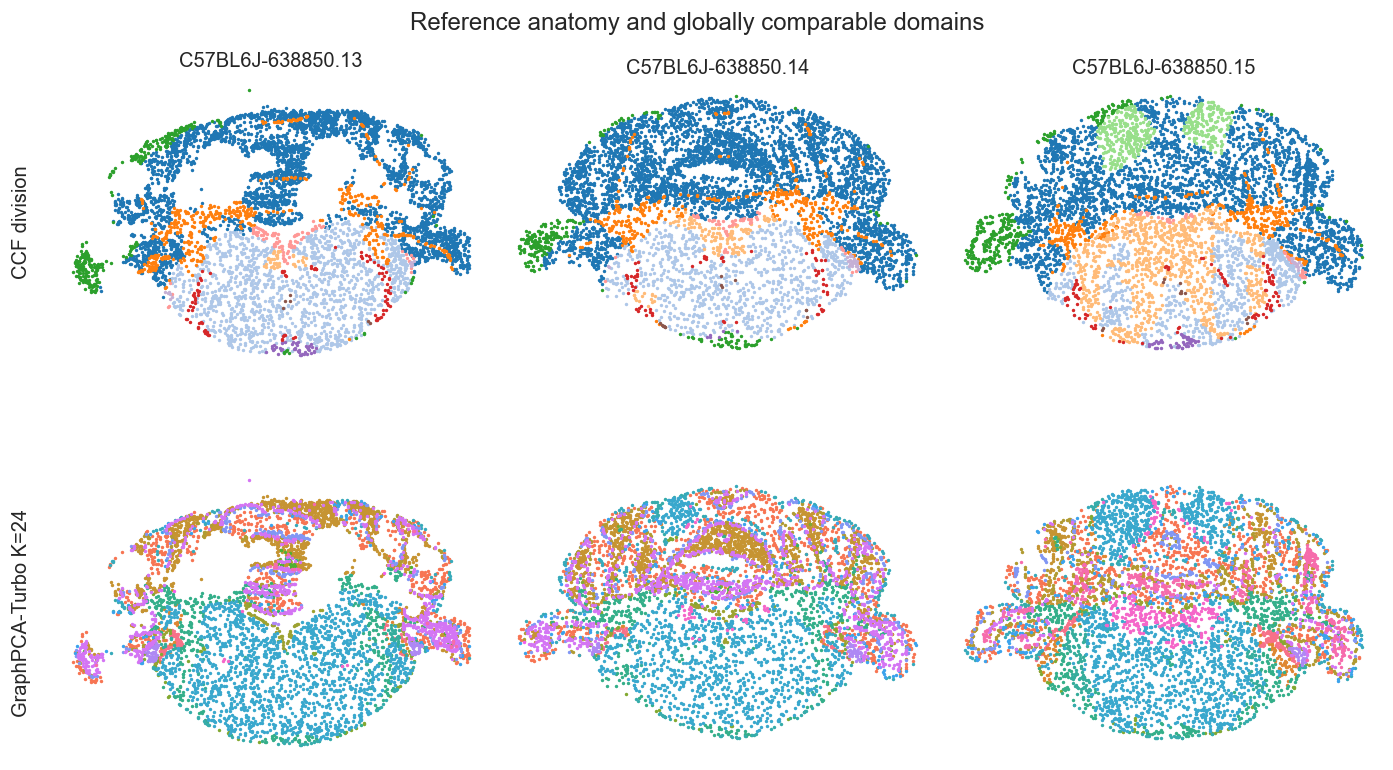

In [6]:
division_order = demo_cells["parcellation_division"].value_counts().index.tolist()
division_palette = dict(zip(division_order, sns.color_palette("tab20", n_colors=len(division_order))))
domain_order = sorted(demo_cells["domain_K24"].unique())
domain_palette = dict(zip(domain_order, sns.color_palette("husl", n_colors=len(domain_order))))

fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.5), constrained_layout=True)
for col, section in enumerate(SECTIONS):
    frame = demo_cells.loc[demo_cells["section"] == section]
    for category in division_order:
        block = frame.loc[frame["parcellation_division"] == category]
        axes[0, col].scatter(block["x_section"], block["y_section"], s=1.1,
                             color=division_palette[category], rasterized=True)
    for category in domain_order:
        block = frame.loc[frame["domain_K24"] == category]
        axes[1, col].scatter(block["x_section"], block["y_section"], s=1.1,
                             color=domain_palette[category], rasterized=True)
    axes[0, col].set_title(section)
    for row in range(2):
        axes[row, col].set_aspect("equal")
        axes[row, col].invert_yaxis()
        axes[row, col].axis("off")

axes[0, 0].text(-0.05, 0.5, "CCF division", transform=axes[0, 0].transAxes,
                ha="right", va="center", rotation=90)
axes[1, 0].text(-0.05, 0.5, "GraphPCA-Turbo K=24", transform=axes[1, 0].transAxes,
                ha="right", va="center", rotation=90)
fig.suptitle("Reference anatomy and globally comparable domains", y=1.02)
plt.show()

The three sections share broad anatomical compartments but are not expected to be identical. Their changing outlines and label composition provide the serial anatomical context for interpreting shared programs.

## 5. Visualize shared molecular programs

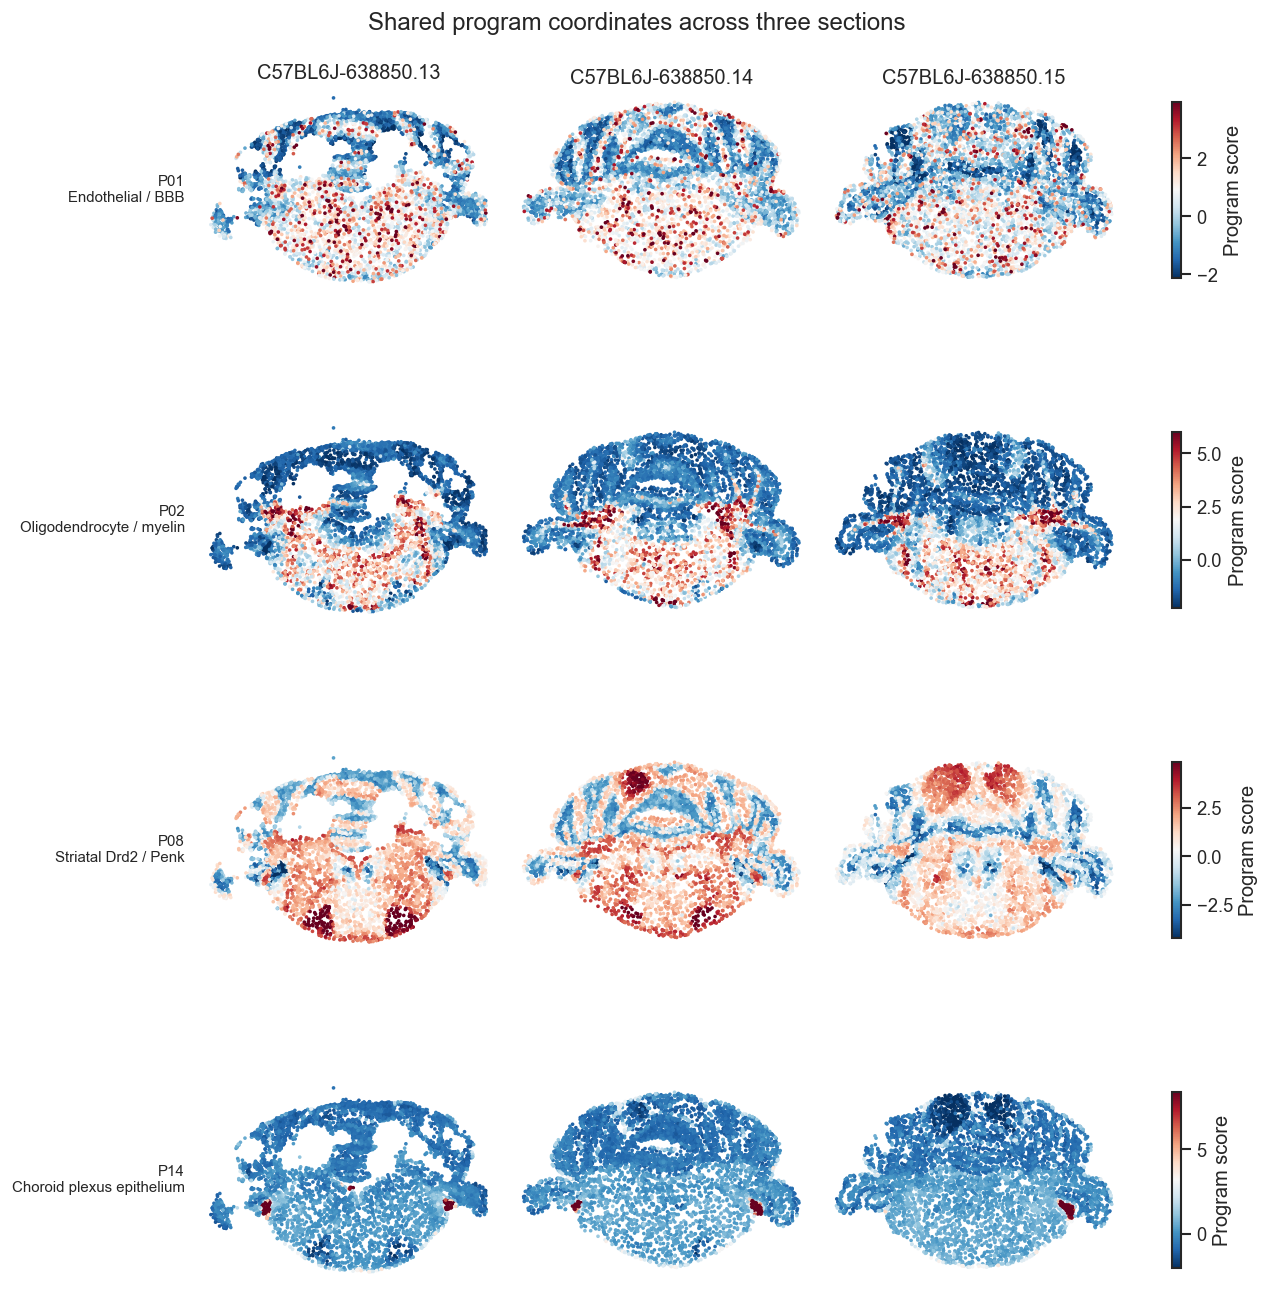

In [7]:
programs_to_map = ["P01", "P02", "P08", "P14"]
fig, axes = plt.subplots(len(programs_to_map), len(SECTIONS), figsize=(10.5, 11), constrained_layout=True)

for row, program in enumerate(programs_to_map):
    lo, hi = demo_cells[program].quantile([0.01, 0.99])
    for col, section in enumerate(SECTIONS):
        ax = axes[row, col]
        frame = demo_cells.loc[demo_cells["section"] == section]
        points = ax.scatter(
            frame["x_section"], frame["y_section"], c=frame[program],
            s=1.4, cmap="RdBu_r", vmin=lo, vmax=hi, rasterized=True,
        )
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.axis("off")
        if row == 0:
            ax.set_title(section)
        if col == 0:
            ax.text(-0.04, 0.5, f"{program}\n{PROGRAM_LABELS[program]}",
                    transform=ax.transAxes, ha="right", va="center", fontsize=9)
    fig.colorbar(points, ax=axes[row, :], shrink=0.55, label="Program score")

fig.suptitle("Shared program coordinates across three sections", y=1.01)
plt.show()

The same program index has the same loading definition in every section. Therefore, cross-section changes in a score map describe altered spatial deployment of one shared molecular axis rather than an attempt to match independently ordered components after fitting.

## 6. Connect programs to leading genes

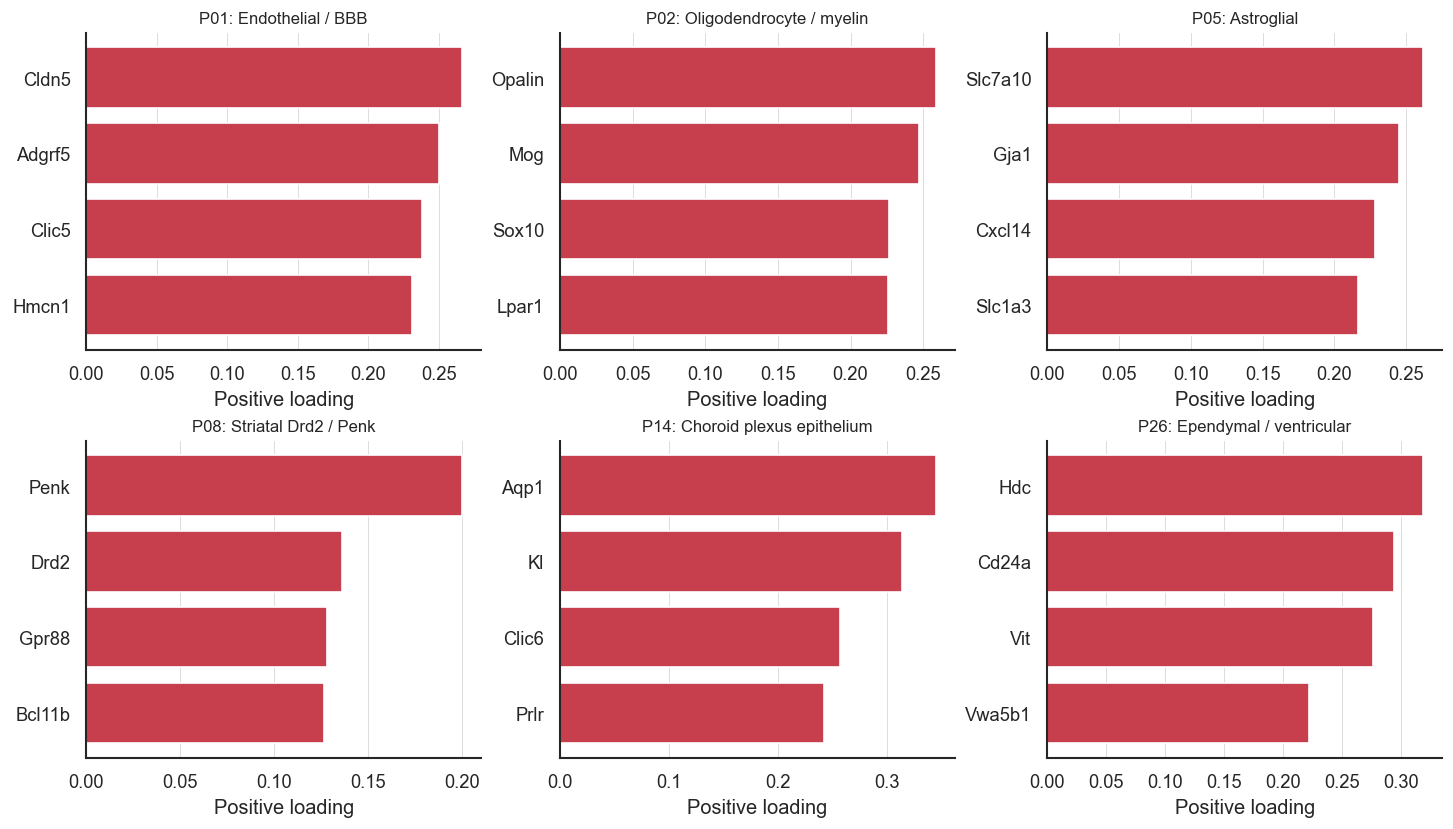

,program,interpretation,gene,rank,loading,subclass_eta_squared,signed_coherence
0,P01,Endothelial / BBB,Cldn5,1,0.266471,0.553106,0.38839
1,P01,Endothelial / BBB,Adgrf5,2,0.249766,0.553106,0.38839
2,P01,Endothelial / BBB,Clic5,3,0.238109,0.553106,0.38839
3,P01,Endothelial / BBB,Hmcn1,4,0.230552,0.553106,0.38839
4,P02,Oligodendrocyte / myelin,Opalin,1,0.258902,0.560680,0.49393
5,P02,Oligodendrocyte / myelin,Mog,2,0.247114,0.560680,0.49393
6,P02,Oligodendrocyte / myelin,Sox10,3,0.226601,0.560680,0.49393
7,P02,Oligodendrocyte / myelin,Lpar1,4,0.226037,0.560680,0.49393
8,P05,Astroglial,Slc7a10,1,0.261857,0.537752,0.35839
9,P05,Astroglial,Gja1,2,0.245312,0.537752,0.35839


In [8]:
program_evidence = pd.read_csv(ASSET_DIR / "program_evidence.csv")

fig, axes = plt.subplots(2, 3, figsize=(12, 6.8), constrained_layout=True)
for ax, (program, label) in zip(axes.flat, PROGRAM_LABELS.items()):
    frame = program_evidence.loc[program_evidence["program"] == program].sort_values("loading")
    ax.barh(frame["gene"], frame["loading"], color="#C73E4D")
    ax.set_title(f"{program}: {label}", fontsize=10)
    ax.set_xlabel("Positive loading")
    ax.grid(axis="x", color="#dddddd", linewidth=0.6)
plt.show()

program_evidence[["program", "interpretation", "gene", "rank", "loading",
                  "subclass_eta_squared", "signed_coherence"]].head(12)

Program names are post hoc interpretations supported jointly by leading positive loadings, spatial localization, annotation association, and expression coherence. The CCF and subclass labels are not used to fit the representation.

## 7. Summarize anatomical associations

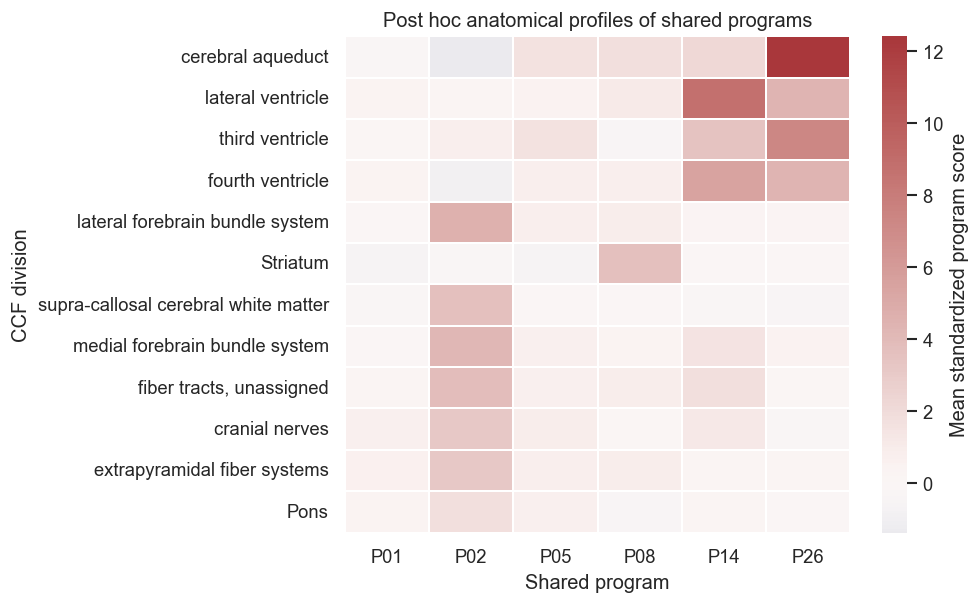

In [9]:
division_means = pd.read_csv(ASSET_DIR / "division_program_means.csv").set_index("CCF division")
division_means.columns = [f"P{int(column.split('_')[1]):02d}" for column in division_means.columns]

# Keep divisions with the largest variation across the six displayed programs.
display_divisions = division_means.var(axis=1).nlargest(12).index
plot_data = division_means.loc[display_divisions, list(PROGRAM_LABELS)]

plt.figure(figsize=(8.4, 5.2))
sns.heatmap(plot_data, cmap="vlag", center=0, linewidths=0.25,
            cbar_kws={"label": "Mean standardized program score"})
plt.xlabel("Shared program")
plt.ylabel("CCF division")
plt.title("Post hoc anatomical profiles of shared programs")
plt.tight_layout()
plt.show()

## 8. Check section-specific loading refinement

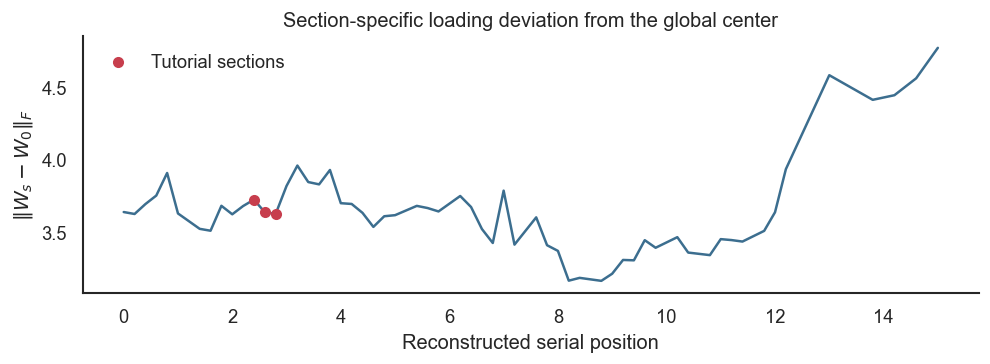

In [10]:
loading_deviation = pd.read_csv(ASSET_DIR / "section_loading_deviation.csv").sort_values("z_section")

fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.plot(loading_deviation["z_section"], loading_deviation["loading_deviation"],
        color="#3C6E8F", linewidth=1.5)
selected = loading_deviation["section"].isin(SECTIONS)
ax.scatter(loading_deviation.loc[selected, "z_section"],
           loading_deviation.loc[selected, "loading_deviation"],
           color="#C73E4D", s=32, zorder=3, label="Tutorial sections")
ax.set(xlabel="Reconstructed serial position", ylabel=r"$\|W_s-W_0\|_F$",
       title="Section-specific loading deviation from the global center")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

`W_0` defines the comparable shared coordinate, while `W_s - W_0` records section-specific refinement. The deviation curve is a diagnostic, not a batch-removal score: serial position can contain real biological variation.

## 9. Check serial continuity

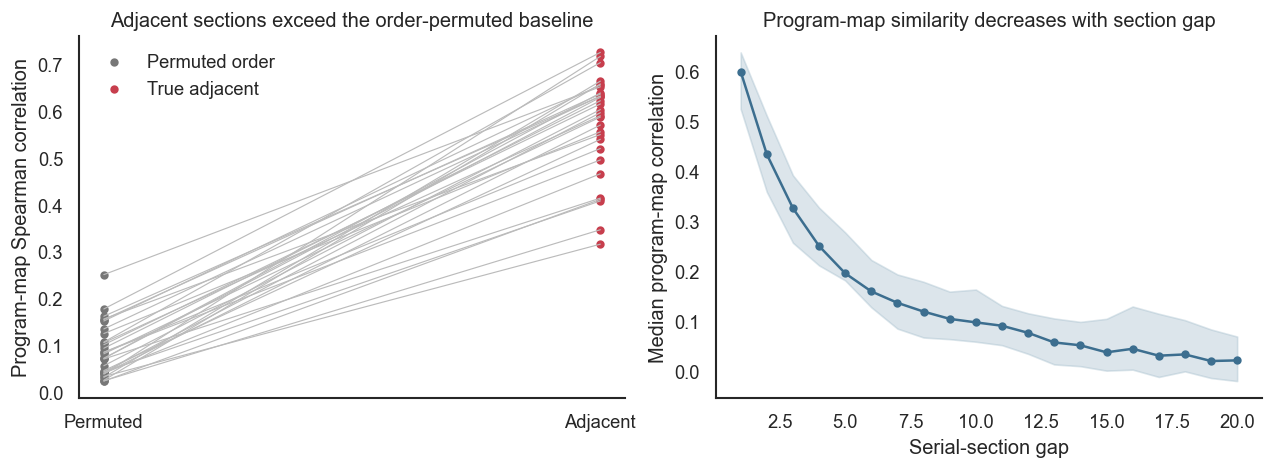

In [11]:
adjacency = pd.read_csv(ASSET_DIR / "continuity_adjacent_vs_null.csv")
gap_decay = pd.read_csv(ASSET_DIR / "continuity_gap_decay.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for _, row in adjacency.iterrows():
    axes[0].plot([0, 1], [row["null"], row["observed"]], color="#bbbbbb", linewidth=0.7)
axes[0].scatter(np.zeros(len(adjacency)), adjacency["null"], color="#777777", s=16, label="Permuted order")
axes[0].scatter(np.ones(len(adjacency)), adjacency["observed"], color="#C73E4D", s=16, label="True adjacent")
axes[0].set_xticks([0, 1], ["Permuted", "Adjacent"])
axes[0].set_ylabel("Program-map Spearman correlation")
axes[0].set_title("Adjacent sections exceed the order-permuted baseline")
axes[0].legend(frameon=False)

axes[1].fill_between(gap_decay["gap"], gap_decay["q25"], gap_decay["q75"], color="#9BB7C7", alpha=0.35)
axes[1].plot(gap_decay["gap"], gap_decay["median"], marker="o", color="#3C6E8F", markersize=4)
axes[1].set(xlabel="Serial-section gap", ylabel="Median program-map correlation",
            title="Program-map similarity decreases with section gap")
plt.show()

These diagnostics test whether shared program maps retain the known serial arrangement. They do not use serial position during model fitting: section order enters only after fitting, when map correlations are compared across true and permuted section pairs.

## Checks

In [12]:
assert set(SECTIONS) == set(demo_cells["section"].unique())
assert not demo_cells[list(PROGRAM_LABELS)].isna().any().any()
assert (section_manifest["n_cells"] > 0).all()
assert program_evidence.groupby("program")["gene"].nunique().eq(4).all()
print("Checks passed: three sections, six finite program scores, and four displayed loading genes per program.")

Checks passed: three sections, six finite program scores, and four displayed loading genes per program.


## Next steps

For a complete local analysis, point `RAW_H5AD`, `STORE_ROOT`, and `MODEL_DIR` to the full files, set `RUN_FULL_DATA=True`, and replace the compact plotting table with all cells or a reproducible downsample. The same workflow can then be extended to all 59 sections and all 30 shared programs. Keep one common rotation for every section and report section-specific refinements separately from the global loading center.